In [17]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sarvagyasingh15","key":"3c1e16e78e66e5eb0e51ce4084121f4c"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d salader/dogsvscats


Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [01:00<00:00, 18.8MB/s]



Here we downloaded the dataset from Kaggle for our processing. But we got the data into the zip format so to unzip it we are doing the steps in the below cell.

In [ ]:
import zipfile
zip_ref = zipfile.ZipFile("/content/dogsvscats.zip", "r")
zip_ref.extractall("/content")
zip_ref.close()

We have unzipped our data using this code cell.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Input,MaxPooling2D
from tensorflow.keras import Sequential

We have a vast amount of data so we cannot upload all the data and train consistently on all the inputs together. Here we have to divide the dataset into batches using generators. Generators are especially those which divide our dataset into batches so that so that my RAM does not get overloaded, divide the data into batches. We are using `keras.utils.image_dataset_from_directory` for the efficient loading of data into the batches.

In [54]:
train_ds=keras.utils.image_dataset_from_directory(
    directory="/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)
test_ds=keras.utils.image_dataset_from_directory(
    directory="/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


Through this we have inherited the data into the numpy array but the thing is that the pixel values lie from 0 to 255, which is a very huge difference. To normalize it we have to use normalization technique

In [99]:
def process(image,label):
  image = tf.cast(image / 255., tf.float32)
  return image, label
train_ds = train_ds.map(process)
test_ds = test_ds.map(process)


In [56]:
model = Sequential()
model.add(Input(shape=(256,256,3)))
model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu"))
model.a
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(64,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(128,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [57]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [58]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history= model.fit(train_ds,epochs=10,validation_data=test_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 83ms/step - accuracy: 0.6370 - loss: 0.6276 - val_accuracy: 0.7266 - val_loss: 0.5335
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.7572 - loss: 0.4938 - val_accuracy: 0.7886 - val_loss: 0.4487
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 89ms/step - accuracy: 0.8314 - loss: 0.3738 - val_accuracy: 0.7900 - val_loss: 0.5145
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 83ms/step - accuracy: 0.8968 - loss: 0.2420 - val_accuracy: 0.7758 - val_loss: 0.7419
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.9509 - loss: 0.1248 - val_accuracy: 0.7792 - val_loss: 0.8792
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.9711 - loss: 0.0779 - val_accuracy: 0.7786 - val_loss: 0.9755
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.9801 - loss: 0.0593 - val_accuracy: 0.7752 - val_loss: 1.3791
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.9890 - loss: 0.0393 - 

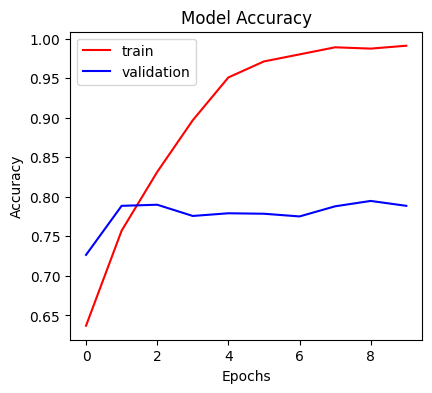

In [60]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

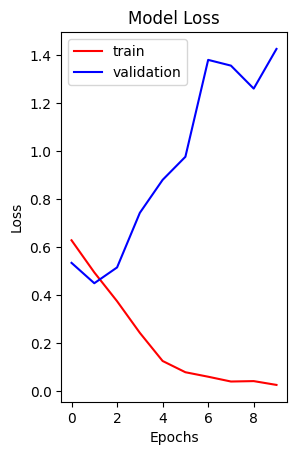

In [61]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

After the observation we come to the conclusion that my accuracy is very low and constant after semi-boost and my loss is much higher. To overcome it we are going to use these steps because I think it's due to overfitting:
- regularization
- dropout
- reduced complexity
- batch normalization of the batches
It may give us the best result but for now I'm skipping it because it's very time-consuming to run the epochs, taking about 10 minutes, approx., to run the 10 epochs. We will do it afterwards. For now we have understood how and what the understandings are.
1. regularization
2. dropouts
3. reduced complexity
4. batch normalization

*We* can apply these to reduce overfitting and have much more accuracy for our given datasets.

In [125]:
import numpy as np, tensorflow as tf

CLASS_NAMES = ["cat", "dog"]  # alphabetical folder order

def predict_image(path, model):
    img = tf.keras.utils.load_img(path, target_size=(256, 256), interpolation="bilinear")  # RGB
    x = tf.keras.utils.img_to_array(img) / 255.0
    x = np.expand_dims(x, 0).astype("float32")
    p = float(model.predict(x, verbose=0)[0][0])      # P(dog)
    label = CLASS_NAMES[int(p > 0.5)]
    return label, p if p > 0.5 else 1 - p

print(predict_image("/content/NationalGeographic_2572187_16x9.avif", model))

('cat', 0.9999559495227004)


In [127]:
print(predict_image("/content/45DC32F6-0D37-4B15-BFBED5850E52D723_source.webp", model))

('dog', 0.9830009937286377)


This was a nightmare for me to predict the cat and dog. Eventually we haven't finished with it. We need to have some good neural network with dropouts and normalization, reduce the complexity, and add regularization but for now it's much better. We'll continue it afterwards.